
---
title: "Using Python to Calculate Shortest Travel Time with the GRID3 Nigeria Friction Surface"
date: "2026-03-31"
author: "Matthew Walter"
order: 1

---



In this guide we demonstrate how to use GRID3’s friction surface to calculate the shortest travel time between two points using open source Python packages. For calculating the lowest cost path, we use route_through_array in skimage. We use the Nigeria mixed travel friction surface for
this demonstration. If you already have the friction surface, a start and an end point, you can skip to Step 3.

# Step 1: Set up libraries and file path

In [ ]:
import os
import zipfile
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import matplotlib.pyplot as plt
from pyproj import Transformer
from skimage.graph import route_through_array
import math

In [ ]:
# Set the file path for storing and reading in the friction surface
path = '/content/extracted_data'

# Step 2: Read in and clip friction surface (skip to Step 3 if you have already downloaded the desired friction surface)

In [ ]:
# Download the zip file for the mixed friction surface for Nigeria
!wget {'https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download'} -O {'GRID3_NGA_mix_travel_time_friction_surface_v1_0.zip'}

# Make sure directory exists
os.makedirs(path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile('GRID3_NGA_mix_travel_time_friction_surface_v1_0.zip', 'r') as zip_ref:
    zip_ref.extractall(path)

--2026-03-26 17:42:47--  https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download
Resolving academiccommons.columbia.edu (academiccommons.columbia.edu)... 128.59.222.111
Connecting to academiccommons.columbia.edu (academiccommons.columbia.edu)|128.59.222.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3224743565 (3.0G) [application/zip]
Saving to: ‘GRID3_NGA_mix_travel_time_friction_surface_v1_0.zip’

GRID3_NGA_mix_trave 100%[===================>]   3.00G  49.1MB/s    in 63s     

2026-03-26 17:43:51 (48.7 MB/s) - ‘GRID3_NGA_mix_travel_time_friction_surface_v1_0.zip’ saved [3224743565/3224743565]



In [ ]:
# Set bounding box lat and long for clipping
bbox = 7.503662,12.885811,7.767334,13.105382

# Transform CRS to UTM to match friction surface
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
bbox = transformer.transform_bounds(*bbox)

# Set bounding box corners
minx, miny, maxx, maxy = bbox

In [ ]:
# Open and clip friction surface
with rasterio.open(f'{path}/GRID3_NGA_mix_travel_time_friction_surface_v1_0/GRID3_NGA_mix_travel_time_friction_surface_v1_0.tif') as src:
    # Get the window corresponding to the bounds in the raster's CRS
    window = from_bounds(minx, miny, maxx, maxy, src.transform)

    # Read the raster and metadata from that specific window
    clipped_data = src.read(1,window=window)
    transform=src.transform
    profile = src.meta

# Update the profile dictionary with the correct dimensions and transform for clipped_data
updated_profile = profile.copy()
updated_profile['height'] = clipped_data.shape[0]
updated_profile['width'] = clipped_data.shape[1]

# Recalculate the transform for the clipped data
updated_profile['transform'] = rasterio.transform.from_origin(bbox[0], bbox[3], abs(transform.a), abs(transform.e))

# Set path for clipped friction surface
fs_path = os.path.join(path, 'fs_clip.tif')
# Write out clipped data to file
with rasterio.open(fs_path, 'w', **updated_profile) as dst:
  dst.write(clipped_data, 1)


# Step 3: Calculate Distance Between Points

In [ ]:
# Create two points for distance calculation using lat and long
pt1 = 7.515850,13.034015
pt2 = 7.682362,12.923887

# Transform to UTM to match friction surface
pt1 = transformer.transform(*pt1)
pt2 = transformer.transform(*pt2)

Text(0.5, 1.0, 'Travel time = 41 minutes')

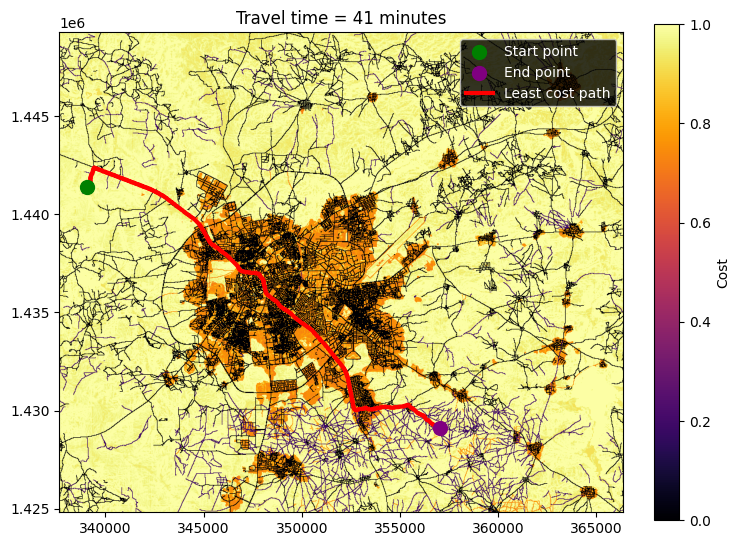

In [ ]:
# Open clipped dataset and calculate distance between two points

# Read in clipped friction surface (replace fs_path with your friction surface path if desired)
fs = rasterio.open(fs_path)

# Add friction surface to map
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
show(fs, transform=transform, cmap='inferno', ax=ax, percent_range=(10, 70))
img = ax.get_images()[0]

plt.colorbar(img, ax=ax, fraction=0.04, label="Cost")

# Add points to map
start_point = ax.scatter(pt1[0], pt1[1], color="green", marker="o", s=100,label="Start point", zorder=2)
end_point = ax.scatter(pt2[0], pt2[1], color="purple", marker="o", s=100,label="End point", zorder=2)

#  Get raster array index for start and end points
start_row_ix, start_col_ix = fs.index(x=pt1[0], y=pt1[1])
end_row_ix, end_col_ix = fs.index(x=pt2[0], y=pt2[1])

# Calculate lowest cost path, Use geometric=True to correctly account for diagonal vs. non-diagonal distances in cost calculation
path, cost = route_through_array(array=clipped_data, start=(start_row_ix, start_col_ix), end=(end_row_ix, end_col_ix), geometric=True)

# Convert row and column indexes to coordinates for plotting
row_ind = [x[0] for x in path]
path_ind = [x[1] for x in path]
path_x_coords, path_y_coords = fs.xy(row=row_ind, col=path_ind)

# Plot shortest path
cost_path = ax.plot(path_x_coords, path_y_coords, color="red", lw=3, label="Least cost path", zorder=1)[0]

# Add legend
ax.legend(handles=[start_point, end_point, cost_path], labelcolor="white",facecolor="black")

# Convert accumulated cost time from minutes per meter to total travel time by multiplying accumulated cost by raster cell size
cell_resolution_meters = fs.res[0]
travel_time = str(round(cost * cell_resolution_meters, 0).astype(int))

# Add travel time as plot title
plt.title(f"Travel time = {travel_time} minutes")